## <h3 align="center"> __Johns Hopkins University__</h3>
## <h3 align="center">__Whiting School of Engineering__</h3>
## <h3 align="center">__Engineering for Professionals__</h3>
## <h3 align="center">__685.801 Data Science: Independent Study__</h3>
## <h3 align="center">__Serialized Backbone Comparison__</h3>

---

- **Purpose:** Compare backbone families across the serialized MoE runs without retraining.
- **Backbones compared:** `MobileNet`, `ConvNeXt`, `JE MobileNet`, and `JE ConvNeXt`.
- **Primary metric:** `AvgAcc Micro F1`.
- **Statistical testing:** paired Wilcoxon signed-rank with Benjamini-Hochberg correction, pairing on identical router and expert choices.
- **How to use:**
  1. Update the results path cell if needed.
  2. Run the notebook top to bottom.
  3. Review the summary tables, paired deltas, significance tables, and separate figures.

---

In [1]:
! pip install -q numpy pandas matplotlib seaborn scipy statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Dom\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Environment check
import sys, platform
print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
try:
    import numpy as np, pandas as pd, matplotlib, seaborn, scipy, statsmodels
    print(f'numpy:      {np.__version__}')
    print(f'pandas:     {pd.__version__}')
    print(f'matplotlib: {matplotlib.__version__}')
    print(f'seaborn:    {getattr(seaborn, "__version__", "unknown")}')
    print(f'scipy:      {scipy.__version__}')
    print(f'statsmodels:{statsmodels.__version__}')
except Exception as exc:
    print('Optional packages missing or version check failed:', exc)
    print('Use the command in the cell above to install necessary packages.')

Python: 3.12.10
Platform: Windows-11-10.0.26200-SP0
numpy:      1.26.4
pandas:     2.2.2
matplotlib: 3.9.2
seaborn:    0.13.2
scipy:      1.14.1
statsmodels:0.14.4


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

from plots import load_serialized_training_runs, build_serialized_results_table

In [4]:
RESULTS_DIR = Path('./results')
RESULT_GLOB = '*.json'
BACKBONE_ORDER = ['MobileNet', 'ConvNeXt', 'JE MobileNet', 'JE ConvNeXt']
BASELINE_BACKBONE = 'MobileNet'

all_paths = sorted(RESULTS_DIR.glob(RESULT_GLOB))
result_paths = [path for path in all_paths if ' + ' in path.stem]
if not result_paths:
    raise FileNotFoundError('No JSON files were found. Update RESULTS_DIR or RESULT_GLOB before continuing.')

pd.DataFrame({'Result File': [str(path) for path in result_paths]})

,Result File
0,results\ConvNeXt + Layered Router + MLP Expert...
1,results\ConvNeXt + Layered Router + ResMLP Exp...
2,results\ConvNeXt + Layered Router + Transforme...
3,results\ConvNeXt + MLP Router + MLP Experts_20...
4,results\ConvNeXt + MLP Router + ResMLP Experts...
5,results\ConvNeXt + MLP Router + Transformer Ex...
6,results\JE ConvNeXt Tiny + Layered Router + ML...
7,results\JE ConvNeXt Tiny + Layered Router + Re...
8,results\JE ConvNeXt Tiny + Layered Router + Tr...
9,results\JE ConvNeXt Tiny + MLP Router + MLP Ex...


In [5]:
def add_model_component_columns(df: pd.DataFrame):
    if 'Model' not in df.columns:
        raise KeyError("Expected a 'Model' column in the comparison dataframe.")

    parts = df['Model'].astype(str).str.split(r'\s+\+\s+', expand=True)
    if parts.shape[1] < 3:
        raise ValueError("Expected model names in the form 'Generalist + Router + Expert'.")

    out = df.copy()
    out['Generalist'] = parts[0]
    out['Router'] = parts[1]
    out['Expert'] = parts[2]
    return out


def normalize_backbone_label(generalist_name: str):
    name = str(generalist_name).strip()
    lowered = name.lower()
    if lowered.startswith('je mobilenet'):
        return 'JE MobileNet'
    if lowered.startswith('je convnext'):
        return 'JE ConvNeXt'
    if lowered.startswith('mobilenet'):
        return 'MobileNet'
    if lowered.startswith('convnext'):
        return 'ConvNeXt'
    return np.nan


def flatten_multiindex_columns(df: pd.DataFrame):
    flattened = []
    for col in df.columns:
        if isinstance(col, tuple):
            flattened.append(' '.join(str(part) for part in col if part).strip())
        else:
            flattened.append(str(col))
    result = df.copy()
    result.columns = flattened
    return result


def summarize_component_performance(df: pd.DataFrame, component_col: str, metrics: list[str]):
    available_metrics = [metric for metric in metrics if metric in df.columns]
    if not available_metrics:
        return pd.DataFrame()

    summary = (
        df.groupby(component_col)[available_metrics]
        .agg(['mean'])
        .reset_index()
    )
    summary = flatten_multiindex_columns(summary)
    sort_column = f'{available_metrics[0]} mean'
    if sort_column in summary.columns:
        summary = summary.sort_values(sort_column, ascending=False).reset_index(drop=True)
    return summary


def build_component_delta_table(df: pd.DataFrame, component_col: str, baseline_name: str, compare_names: list[str], fixed_cols: list[str], metrics: list[str]):
    available_metrics = [metric for metric in metrics if metric in df.columns]
    if not available_metrics:
        return pd.DataFrame()

    rows = []
    for compare_name in compare_names:
        subset = df[df[component_col].isin([baseline_name, compare_name])].copy()
        if subset[component_col].nunique() < 2:
            continue

        pivot = subset.pivot_table(index=fixed_cols, columns=component_col, values=available_metrics, aggfunc='first')
        if baseline_name not in pivot.columns.get_level_values(1):
            continue
        if compare_name not in pivot.columns.get_level_values(1):
            continue

        delta_df = pd.DataFrame(index=pivot.index).reset_index()
        delta_df[component_col] = compare_name
        for metric in available_metrics:
            baseline_key = (metric, baseline_name)
            compare_key = (metric, compare_name)
            if baseline_key not in pivot.columns or compare_key not in pivot.columns:
                continue

            baseline_values = pivot[baseline_key].to_numpy()
            compare_values = pivot[compare_key].to_numpy()
            delta_df[f'{metric} [{baseline_name}]'] = baseline_values
            delta_df[f'{metric} [{compare_name}]'] = compare_values
            delta_df[f'{metric} Delta ({compare_name} - {baseline_name})'] = compare_values - baseline_values

        rows.append(delta_df)

    if not rows:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


def run_paired_component_tests(df: pd.DataFrame, component_col: str, baseline_name: str, compare_names: list[str], fixed_cols: list[str], metrics: list[str]):
    available_metrics = [metric for metric in metrics if metric in df.columns]
    if not available_metrics:
        return pd.DataFrame()

    rows = []
    raw_p_values = []
    p_value_row_indices = []

    for compare_name in compare_names:
        subset = df[df[component_col].isin([baseline_name, compare_name])].copy()
        if subset[component_col].nunique() < 2:
            continue

        pivot = subset.pivot_table(index=fixed_cols, columns=component_col, values=available_metrics, aggfunc='first')
        if baseline_name not in pivot.columns.get_level_values(1):
            continue
        if compare_name not in pivot.columns.get_level_values(1):
            continue

        for metric in available_metrics:
            baseline_key = (metric, baseline_name)
            compare_key = (metric, compare_name)
            if baseline_key not in pivot.columns or compare_key not in pivot.columns:
                continue

            paired = pivot[[baseline_key, compare_key]].dropna()
            if paired.empty:
                continue

            baseline_values = paired[baseline_key].to_numpy(dtype=float)
            compare_values = paired[compare_key].to_numpy(dtype=float)
            deltas = compare_values - baseline_values
            nonzero_deltas = deltas[~np.isclose(deltas, 0.0)]

            p_value = np.nan
            test_name = 'Wilcoxon signed-rank'
            if len(nonzero_deltas) == 0:
                p_value = 1.0
                test_name = 'All deltas are zero'
            elif len(nonzero_deltas) >= 2:
                try:
                    _, p_value = wilcoxon(nonzero_deltas, alternative='two-sided', zero_method='wilcox')
                except ValueError:
                    p_value = np.nan
                    test_name = 'Wilcoxon unavailable'
            else:
                test_name = 'Insufficient non-zero pairs'

            row = {
                component_col: compare_name,
                'Metric': metric,
                'Paired Configurations': len(deltas),
                f'Mean {baseline_name}': baseline_values.mean(),
                f'Mean {compare_name}': compare_values.mean(),
                'Mean Delta': deltas.mean(),
                'Median Delta': np.median(deltas),
                'Std Delta': deltas.std(ddof=0),
                'Raw P Value': p_value,
                'Test': test_name,
            }
            rows.append(row)
            if not np.isnan(p_value):
                raw_p_values.append(p_value)
                p_value_row_indices.append(len(rows) - 1)

    if not rows:
        return pd.DataFrame()

    result = pd.DataFrame(rows)
    result['FDR BH P Value'] = np.nan
    result['Significant @ 0.05'] = False
    if raw_p_values:
        _, corrected, _, _ = multipletests(raw_p_values, method='fdr_bh')
        for row_index, corrected_p in zip(p_value_row_indices, corrected):
            result.loc[row_index, 'FDR BH P Value'] = corrected_p
            result.loc[row_index, 'Significant @ 0.05'] = bool(corrected_p < 0.05)

    return result.sort_values([component_col, 'Metric']).reset_index(drop=True)


def style_component_table(df: pd.DataFrame):
    if df.empty:
        return df

    formatters = {}
    for column in df.columns:
        if pd.api.types.is_numeric_dtype(df[column]):
            if 'count' in column.lower() or 'paired configurations' in column.lower():
                formatters[column] = '{:.0f}'
            elif 'Cost Proxy' in column or 'Num Parameters' in column:
                formatters[column] = '{:.0f}'
            else:
                formatters[column] = '{:.4f}'

    return df.style.format(formatters)


runs = load_serialized_training_runs(result_paths)
comparison_df = build_serialized_results_table(runs)
submodel_df = add_model_component_columns(comparison_df)
submodel_df['Backbone'] = submodel_df['Generalist'].map(normalize_backbone_label)
submodel_df['Joint Embedding'] = np.where(submodel_df['Backbone'].astype(str).str.startswith('JE '), 'JE', 'No JE')
submodel_df = submodel_df[submodel_df['Backbone'].isin(BACKBONE_ORDER)].copy()
submodel_df['Backbone'] = pd.Categorical(submodel_df['Backbone'], categories=BACKBONE_ORDER, ordered=True)
submodel_df['Configuration'] = submodel_df['Router'] + ' + ' + submodel_df['Expert']

if submodel_df.empty:
    raise ValueError('No supported backbone runs were found in the results directory.')

primary_metric = 'AvgAcc Micro F1'
primary_bwt_metric = 'Backward Transfer Micro F1'
primary_fwt_metric = 'Forward Transfer Micro F1'
primary_forgetting_metric = 'Average Forgetting Micro F1'
primary_validation_metric = 'Full Validation Micro F1'

summary_columns = [
    column for column in [
        'Model',
        'Backbone',
        'Router',
        'Expert',
        primary_metric,
        primary_bwt_metric,
        primary_fwt_metric,
        primary_forgetting_metric,
        primary_validation_metric,
        'Post Training ECE',
        'Post Training Router Entropy',
        'Post Training Expected Expert Calls',
        'Total Compute Time (s)',
        'Num Parameters',
    ] if column in submodel_df.columns
]
summary_df = submodel_df.loc[:, summary_columns].copy()
summary_df = summary_df.sort_values(by=[primary_metric, primary_validation_metric], ascending=False).reset_index(drop=True)
display(summary_df.style.format({
    primary_metric: '{:.4f}',
    primary_bwt_metric: '{:.4f}',
    primary_fwt_metric: '{:.4f}',
    primary_forgetting_metric: '{:.4f}',
    primary_validation_metric: '{:.4f}',
    'Post Training ECE': '{:.4f}',
    'Post Training Router Entropy': '{:.4f}',
    'Post Training Expected Expert Calls': '{:.4f}',
    'Total Compute Time (s)': '{:.1f}',
    'Num Parameters': '{:,.0f}',
}))

,Model,Backbone,Router,Expert,AvgAcc Micro F1,Backward Transfer Micro F1,Forward Transfer Micro F1,Average Forgetting Micro F1,Full Validation Micro F1,Post Training ECE,Post Training Router Entropy,Post Training Expected Expert Calls,Total Compute Time (s),Num Parameters
0,JE ConvNeXt Tiny + Layered Router + Transformer Experts,JE ConvNeXt,Layered Router,Transformer Experts,0.9847,-0.0217,-0.1369,0.0217,0.9838,0.0116,1.0332,2.0000,1176.6,"29,114,144"
1,JE ConvNeXt Tiny + MLP Router + ResMLP Experts,JE ConvNeXt,MLP Router,ResMLP Experts,0.9823,-0.0225,-0.0968,0.0225,0.9816,0.0078,1.2965,2.0000,1165.5,"28,758,688"
2,JE ConvNeXt Tiny + MLP Router + Transformer Experts,JE ConvNeXt,MLP Router,Transformer Experts,0.9793,-0.0287,-0.1970,0.0287,0.9782,0.0190,1.2646,2.0000,1174.9,"28,981,024"
3,JE ConvNeXt Tiny + Layered Router + MLP Experts,JE ConvNeXt,Layered Router,MLP Experts,0.9751,-0.0363,-0.1192,0.0363,0.9738,0.0061,1.5738,2.0000,1160.8,"28,489,376"
4,JE ConvNeXt Tiny + Layered Router + ResMLP Experts,JE ConvNeXt,Layered Router,ResMLP Experts,0.9745,-0.0352,0.0000,0.0352,0.9732,0.0053,1.1671,2.0000,1167.0,"28,891,808"
5,JE ConvNeXt Tiny + MLP Router + MLP Experts,JE ConvNeXt,MLP Router,MLP Experts,0.9613,-0.0566,-0.1139,0.0566,0.9592,0.0053,1.4883,2.0000,1174.1,"28,356,256"
6,ConvNeXt + Layered Router + MLP Experts,ConvNeXt,Layered Router,MLP Experts,0.9486,-0.0632,-0.1280,0.0632,0.9470,0.0084,0.1365,2.0000,1411.3,"29,615,008"
7,ConvNeXt + MLP Router + MLP Experts,ConvNeXt,MLP Router,MLP Experts,0.9407,-0.0812,-0.1208,0.0812,0.9380,0.0176,1.5120,2.0000,1363.4,"28,429,216"
8,MobileNet + Layered Router + Transformer Experts,MobileNet,Layered Router,Transformer Experts,0.9390,-0.0874,-0.0555,0.0874,0.9355,0.0489,0.6749,2.0000,332.1,"2,434,866"
9,JE MobileNet Small + Layered Router + Transformer Experts,JE MobileNet,Layered Router,Transformer Experts,0.9365,-0.0896,-0.1177,0.0896,0.9330,0.0115,0.8447,2.0000,214.1,"2,173,408"


In [6]:
component_metrics = [
    metric
    for metric in [
        'AvgAcc Micro F1',
        'Backward Transfer Micro F1',
        'Forward Transfer Micro F1',
        'Average Forgetting Micro F1',
        'Full Validation Micro F1',
        'Post Training ECE',
        'Post Training Router Entropy',
        'Post Training Normalized Router Entropy',
        'Post Training Expected Expert Calls',
        'Post Training Cost Proxy',
        'Total Compute Time (s)',
        'Num Parameters',
    ]
    if metric in submodel_df.columns
]

print('Model count by backbone, router, and expert combination')
display(pd.crosstab(submodel_df['Backbone'], [submodel_df['Router'], submodel_df['Expert']]))

backbone_summary_df = summarize_component_performance(submodel_df, 'Backbone', component_metrics)
display(style_component_table(backbone_summary_df))

je_summary_df = summarize_component_performance(submodel_df, 'Joint Embedding', component_metrics)
display(style_component_table(je_summary_df))

Model count by backbone, router, and expert combination


Router       Layered Router                                     MLP Router  \
Expert          MLP Experts ResMLP Experts Transformer Experts MLP Experts   
Backbone                                                                     
MobileNet                 1              1                   1           1   
ConvNeXt                  1              1                   1           1   
JE MobileNet              1              1                   1           1   
JE ConvNeXt               1              1                   1           1   

Router                                           
Expert       ResMLP Experts Transformer Experts  
Backbone                                         
MobileNet                 1                   1  
ConvNeXt                  1                   1  
JE MobileNet              1                   1  
JE ConvNeXt               1                   1

C:\Users\Dom\AppData\Local\Temp\ipykernel_30756\2835253324.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(component_col)[available_metrics]


,Backbone,AvgAcc Micro F1 mean,Backward Transfer Micro F1 mean,Forward Transfer Micro F1 mean,Average Forgetting Micro F1 mean,Full Validation Micro F1 mean,Post Training ECE mean,Post Training Router Entropy mean,Post Training Normalized Router Entropy mean,Post Training Expected Expert Calls mean,Post Training Cost Proxy mean,Total Compute Time (s) mean,Num Parameters mean
0,JE ConvNeXt,0.9762,-0.0335,-0.1106,0.0335,0.9750,0.0092,1.3039,0.7277,2.0000,29311957,1169.8152,28765216
1,ConvNeXt,0.9244,-0.0988,-0.1325,0.0988,0.9213,0.0207,0.7691,0.4292,2.0000,28695206,1372.0794,29236512
2,MobileNet,0.9173,-0.1176,-0.1018,0.1176,0.9128,0.0299,1.3272,0.7407,2.0000,1507256,331.7578,1982258
3,JE MobileNet,0.9166,-0.1185,-0.1261,0.1185,0.9120,0.0208,1.1812,0.6592,2.0000,2371221,198.6737,1824480


,Joint Embedding,AvgAcc Micro F1 mean,Backward Transfer Micro F1 mean,Forward Transfer Micro F1 mean,Average Forgetting Micro F1 mean,Full Validation Micro F1 mean,Post Training ECE mean,Post Training Router Entropy mean,Post Training Normalized Router Entropy mean,Post Training Expected Expert Calls mean,Post Training Cost Proxy mean,Total Compute Time (s) mean,Num Parameters mean
0,JE,0.9464,-0.0760,-0.1184,0.0760,0.9435,0.0150,1.2426,0.6935,2.0000,15841589,684.2445,15294848
1,No JE,0.9209,-0.1082,-0.1172,0.1082,0.9171,0.0253,1.0481,0.5850,2.0000,15101231,851.9186,15609385


## Separate Figures

Each loop below creates one chart per metric as its own figure rather than grouping several metrics into a single subplot grid.

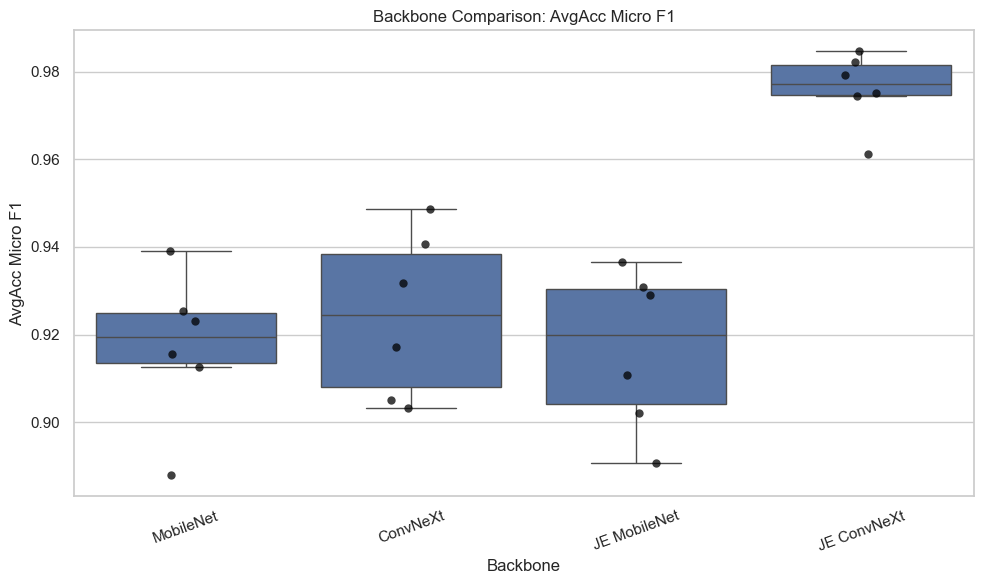

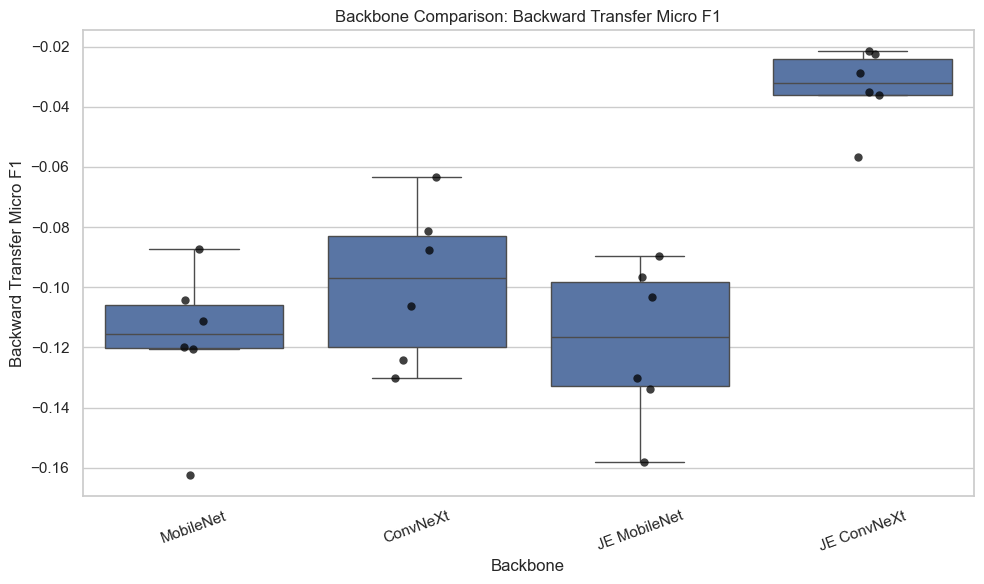

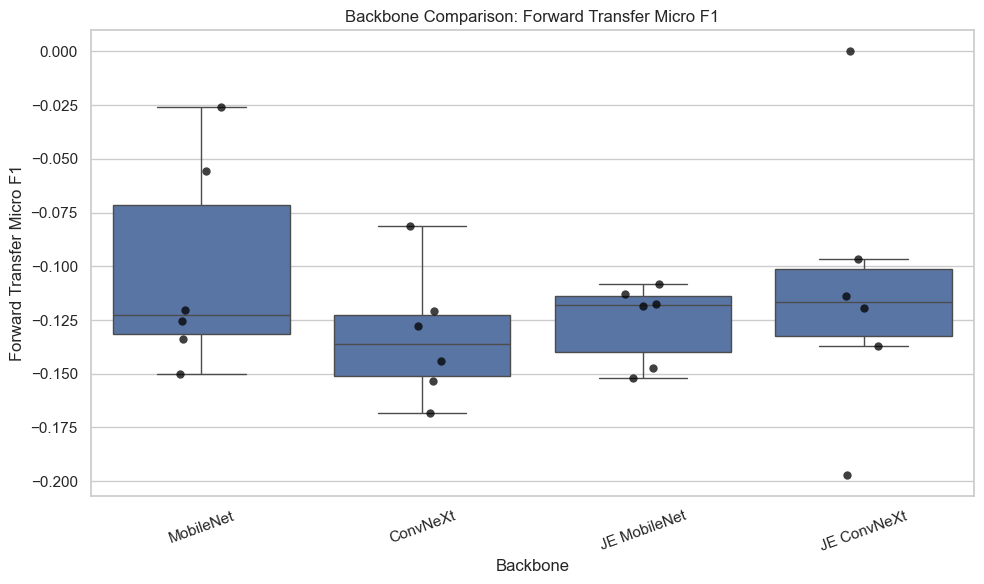

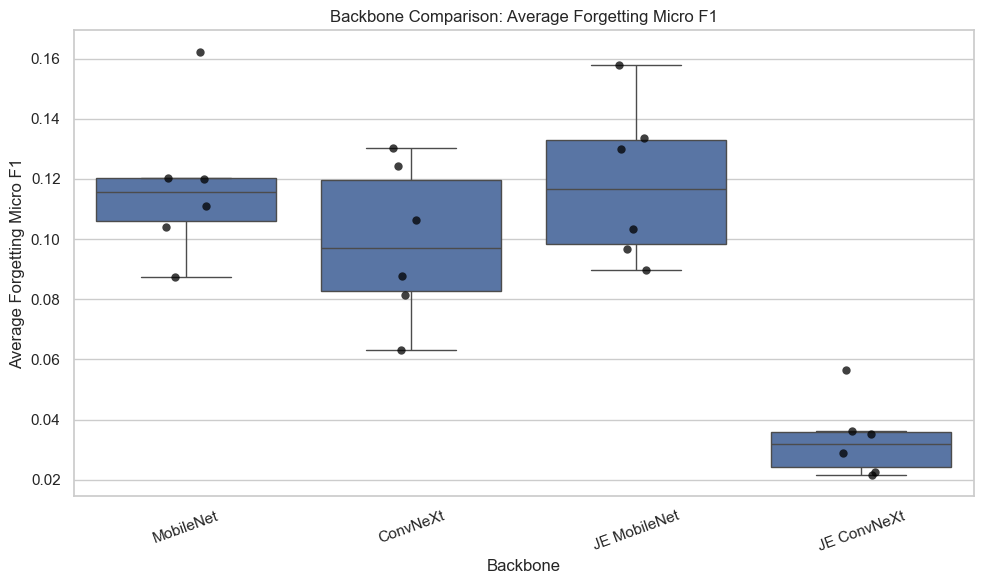

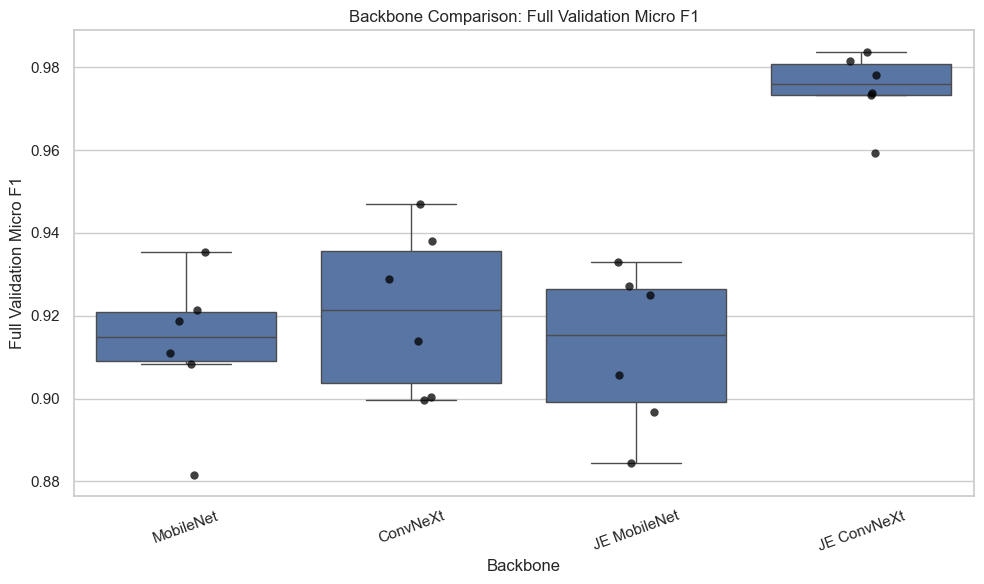

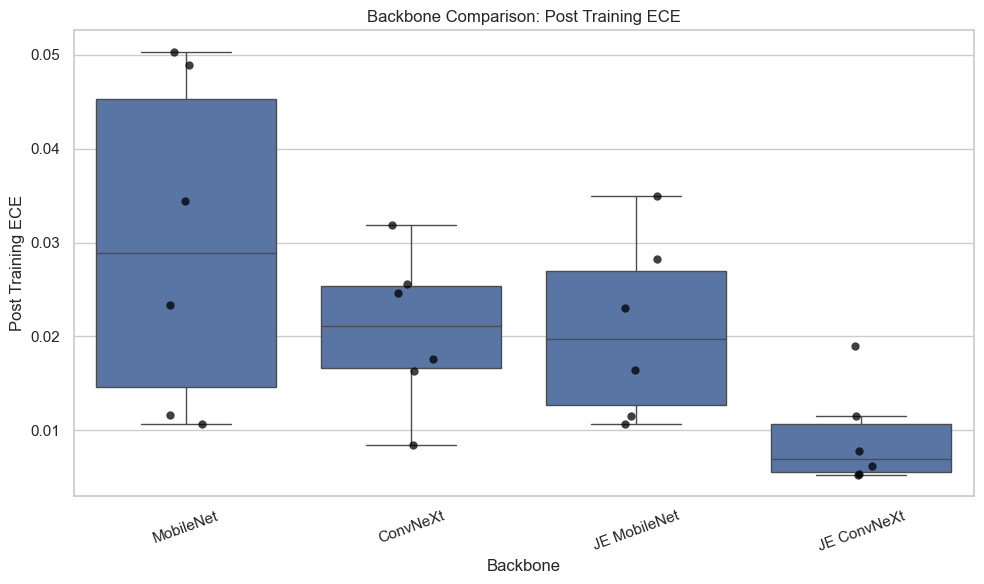

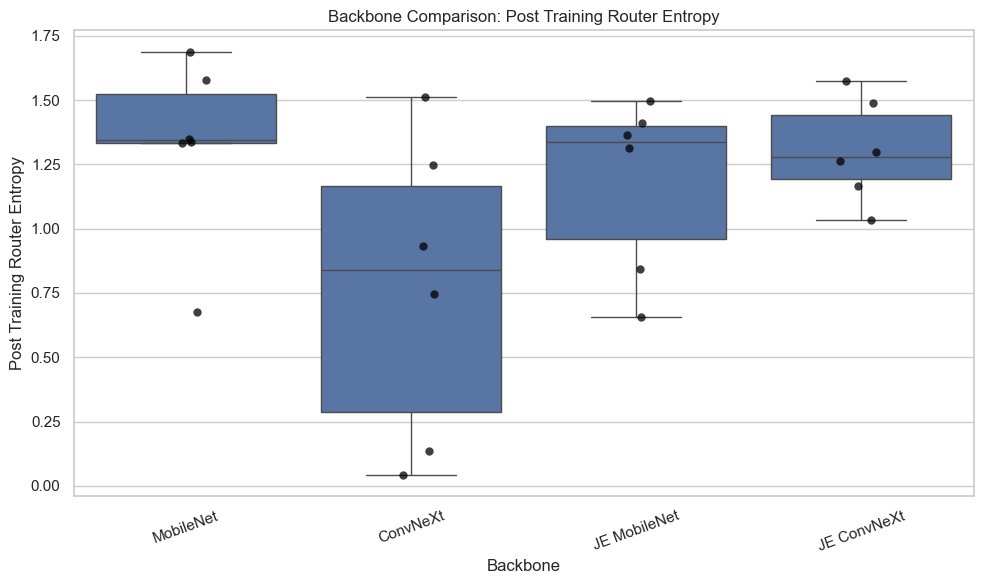

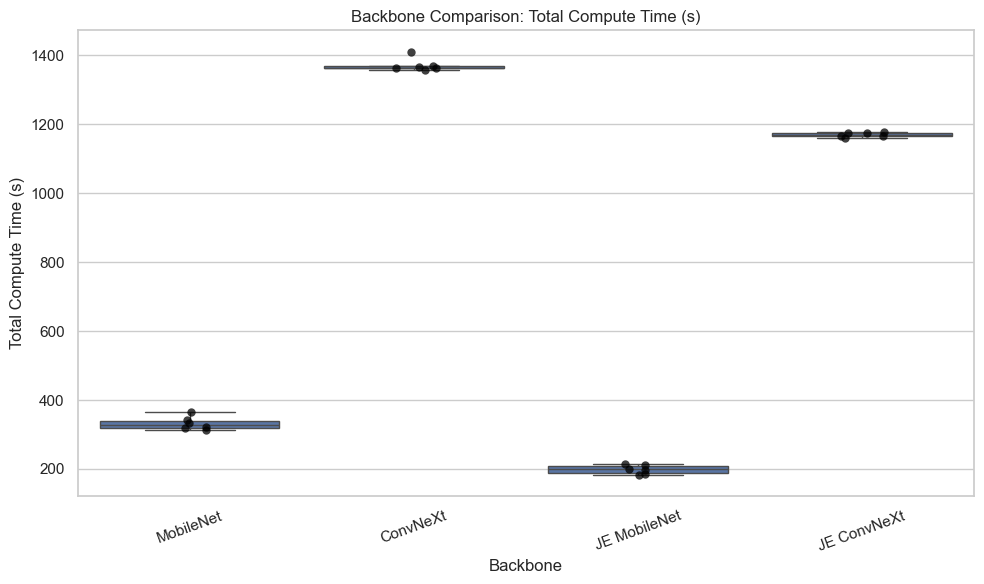

In [13]:
sns.set_theme(style='whitegrid')

backbone_plot_metrics = [
    metric for metric in [
        'AvgAcc Micro F1',
        'Backward Transfer Micro F1',
        'Forward Transfer Micro F1',
        'Average Forgetting Micro F1',
        'Full Validation Micro F1',
        'Post Training ECE',
        'Post Training Router Entropy',
        'Total Compute Time (s)',
    ] if metric in submodel_df.columns
]

for metric in backbone_plot_metrics:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=submodel_df, x='Backbone', y=metric, order=BACKBONE_ORDER, fliersize=0)
    sns.stripplot(data=submodel_df, x='Backbone', y=metric, order=BACKBONE_ORDER, color='black', alpha=0.75, size=6)
    plt.title(f'Backbone Comparison: {metric}')
    plt.xlabel('Backbone')
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

C:\Users\Dom\AppData\Local\Temp\ipykernel_30756\2858872377.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = submodel_df.pivot_table(index='Configuration', columns='Backbone', values=metric, aggfunc='mean')


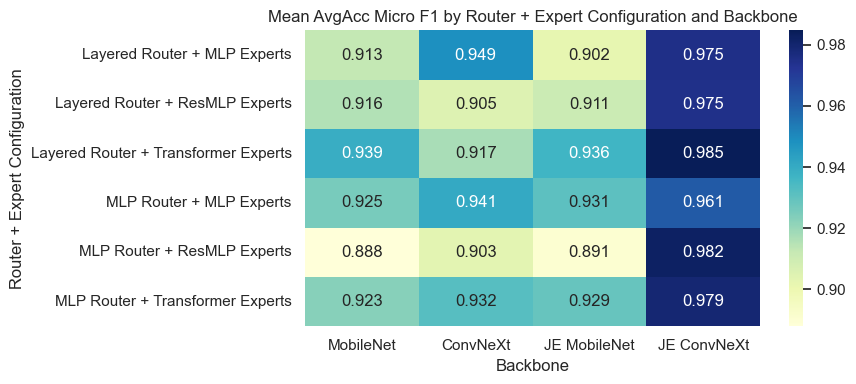

C:\Users\Dom\AppData\Local\Temp\ipykernel_30756\2858872377.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = submodel_df.pivot_table(index='Configuration', columns='Backbone', values=metric, aggfunc='mean')


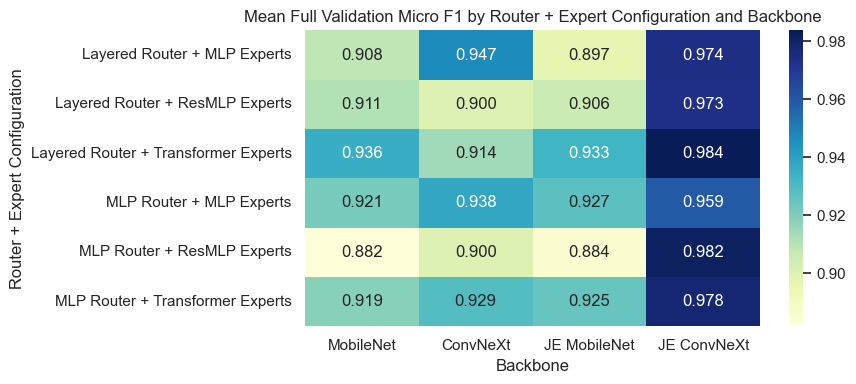

C:\Users\Dom\AppData\Local\Temp\ipykernel_30756\2858872377.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = submodel_df.pivot_table(index='Configuration', columns='Backbone', values=metric, aggfunc='mean')


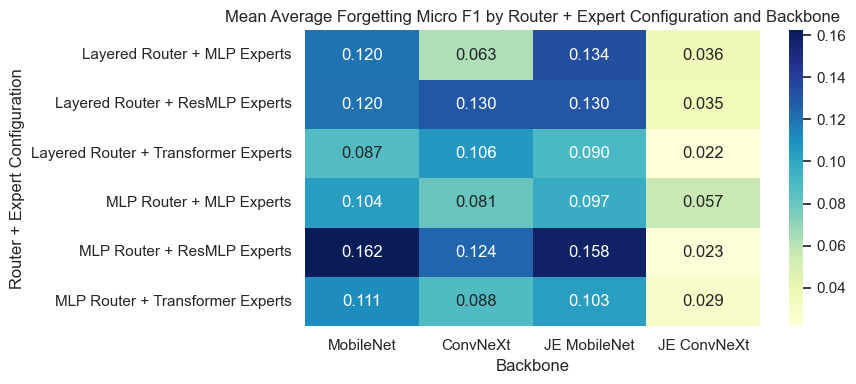

C:\Users\Dom\AppData\Local\Temp\ipykernel_30756\2858872377.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = submodel_df.pivot_table(index='Configuration', columns='Backbone', values=metric, aggfunc='mean')


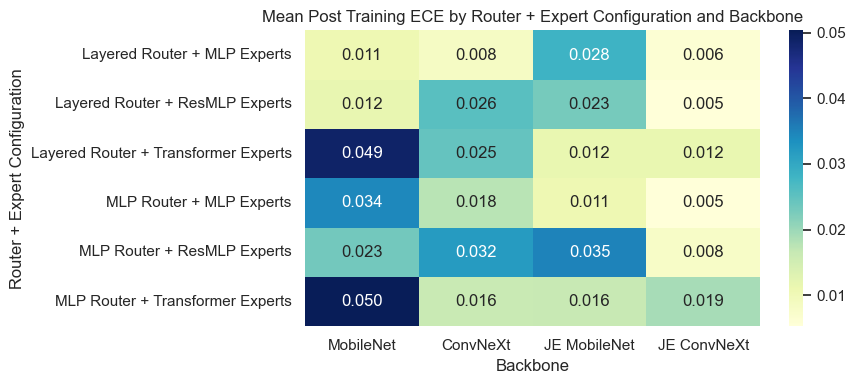

C:\Users\Dom\AppData\Local\Temp\ipykernel_30756\2858872377.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = submodel_df.pivot_table(index='Configuration', columns='Backbone', values=metric, aggfunc='mean')


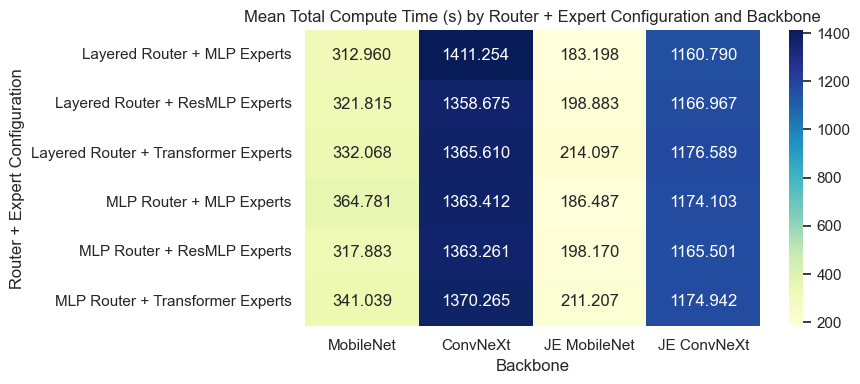

In [9]:
configuration_heatmap_metrics = [
    metric for metric in [
        'AvgAcc Micro F1',
        'Full Validation Micro F1',
        'Average Forgetting Micro F1',
        'Post Training ECE',
        'Total Compute Time (s)',
    ] if metric in submodel_df.columns
]

for metric in configuration_heatmap_metrics:
    pivot = submodel_df.pivot_table(index='Configuration', columns='Backbone', values=metric, aggfunc='mean')
    pivot = pivot.reindex(columns=BACKBONE_ORDER)
    plt.figure(figsize=(9, max(4, len(pivot) * 0.6)))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu')
    plt.title(f'Mean {metric} by Router + Expert Configuration and Backbone')
    plt.xlabel('Backbone')
    plt.ylabel('Router + Expert Configuration')
    plt.tight_layout()
    plt.show()

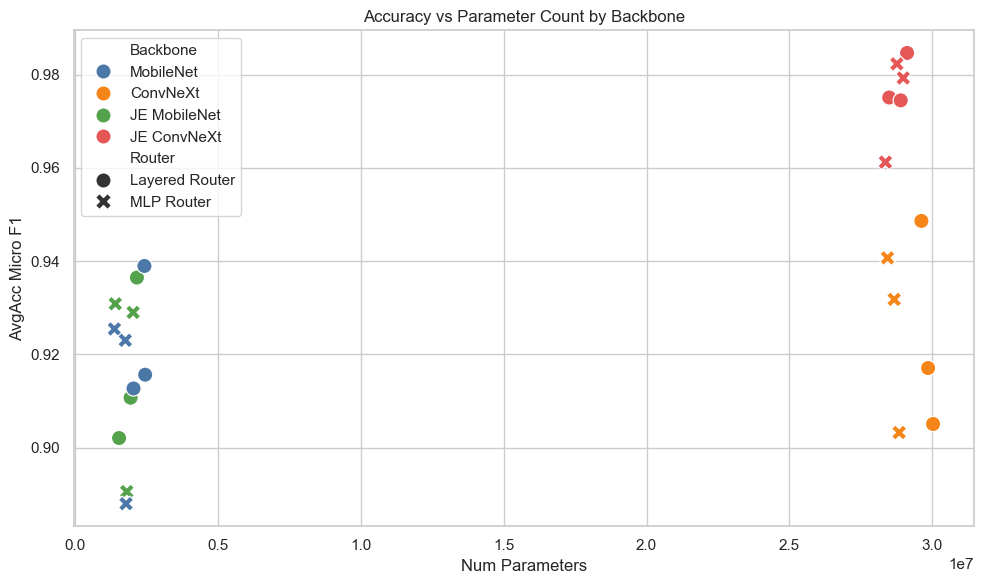

In [10]:
if {'Num Parameters', 'AvgAcc Micro F1', 'Backbone', 'Router'}.issubset(submodel_df.columns):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=submodel_df,
        x='Num Parameters',
        y='AvgAcc Micro F1',
        hue='Backbone',
        style='Router',
        palette=palette,
        s=120,
    )
    plt.title('Accuracy vs Parameter Count by Backbone')
    plt.xlabel('Num Parameters')
    plt.ylabel('AvgAcc Micro F1')
    plt.tight_layout()
    plt.show()